In [10]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno 

# Local src
from src.eda_utils import df_overview
from src.eda_utils import plots

print('Done')

Done


In [ ]:
BG = "#FDFDFD"       
TEXT_COLOR = "#2B2D42"   
GRID_COLOR = "#E2E8F0"  

PINK = "#FF1493"
GREEN = "#00FF41"
PURPLE = "#D100D1"
ORANGERED = "#FF4500"
BLUE = "#1E90FF"
HOTPINK = "#FF69B4"
ORANGE = "#FFA500"
DARKVIOLET = "#9400D3"
TOMATO = "#FF6347"
LIMEGREEN = "#32CD32"
LIGHTSEAGREEN = "#20B2AA"

plt.rcParams.update({
    "savefig.dpi": 300,      
    "savefig.bbox": "tight", 
    
    # Background & colors
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "axes.edgecolor": TEXT_COLOR,

    # Titles & labels
    "axes.titlesize": 18,
    "axes.titlepad": 16,
    "axes.labelsize": 13,
    "axes.labelpad": 10,
    "axes.labelweight": "medium",
    
    # Font
    "font.size": 12,
    "font.family": "Calibri",

    # Lines
    "lines.linewidth": 2.5,
    "lines.markersize": 7,    

    # Grid
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.alpha": 0.6,   
    "grid.linewidth": 0.8,
    "grid.linestyle": "--",
    "axes.axisbelow": True,   

    # Figure
    "figure.figsize": (10, 6),
    "figure.autolayout": False,

    # Spines
    "axes.linewidth": 1.2,

    # Legend
    "legend.facecolor": "#f7f7f7",
    "legend.edgecolor": TEXT_COLOR,
    "legend.framealpha": 1.0,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

sns.set_theme(
    style="whitegrid",   # or "ticks", "darkgrid", etc.
    context="notebook",  # controls scale: paper/notebook/talk/poster
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 3)

print('Done')

Done


In [12]:
path_csv = '../data/03_featured/featured_retail.csv'
df = pd.read_csv(path_csv)
df_overview(df)

================================= Shape =================================
(5847, 11)
================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5847 non-null   int64  
 1   recency          5847 non-null   int64  
 2   frequency        5847 non-null   int64  
 3   monetary         5847 non-null   float64
 4   recency_score    5847 non-null   int64  
 5   frequency_score  5847 non-null   int64  
 6   monetary_score   5847 non-null   int64  
 7   r_f_score        5847 non-null   int64  
 8   segment          5847 non-null   object 
 9   return_ratio     5847 non-null   float64
 10  avg_order_value  5847 non-null   float64
dtypes: float64(3), int64(7), object(1)
memory usage: 502.6+ KB
None
================================= Columns ==========================

- avg recency, frequency and monetary are respectively 196.68, 7.49, 2797.8;

In [13]:
df

,customer_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,r_f_score,segment,return_ratio,avg_order_value
0,12346,325,14,368.360,2,5,2,25,cant_lose,0.995,26.311
1,12347,1,8,"4,921.530",5,4,5,54,champions,0.000,615.191
2,12348,74,5,"1,658.400",3,3,4,33,need_attention,0.000,331.680
3,12349,18,4,"3,654.540",4,3,5,43,potential_loyalists,0.007,913.635
4,12350,309,1,294.400,2,1,2,21,hibernating,0.000,294.400
...,...,...,...,...,...,...,...,...,...,...,...
5842,18283,3,22,"2,658.950",5,5,4,55,champions,0.000,120.861
5843,18284,431,1,411.680,1,2,2,12,hibernating,0.000,411.680
5844,18285,660,1,377.000,1,2,2,12,hibernating,0.000,377.000
5845,18286,476,3,"1,138.430",1,3,3,13,at_risk,0.087,379.477


(<Figure size 1000x4800 with 8 Axes>,
 array([<Axes: title={'center': 'recency'}, ylabel='Count'>,
        <Axes: title={'center': 'frequency'}, ylabel='Count'>,
        <Axes: title={'center': 'monetary'}, ylabel='Count'>,
        <Axes: title={'center': 'return_ratio'}, ylabel='Count'>,
        <Axes: title={'center': 'avg_order_value'}, ylabel='Count'>,
        <Axes: title={'center': 'monetary_score'}, ylabel='Count'>,
        <Axes: title={'center': 'frequency_score'}, ylabel='Count'>,
        <Axes: title={'center': 'recency_score'}, ylabel='Count'>],
       dtype=object))

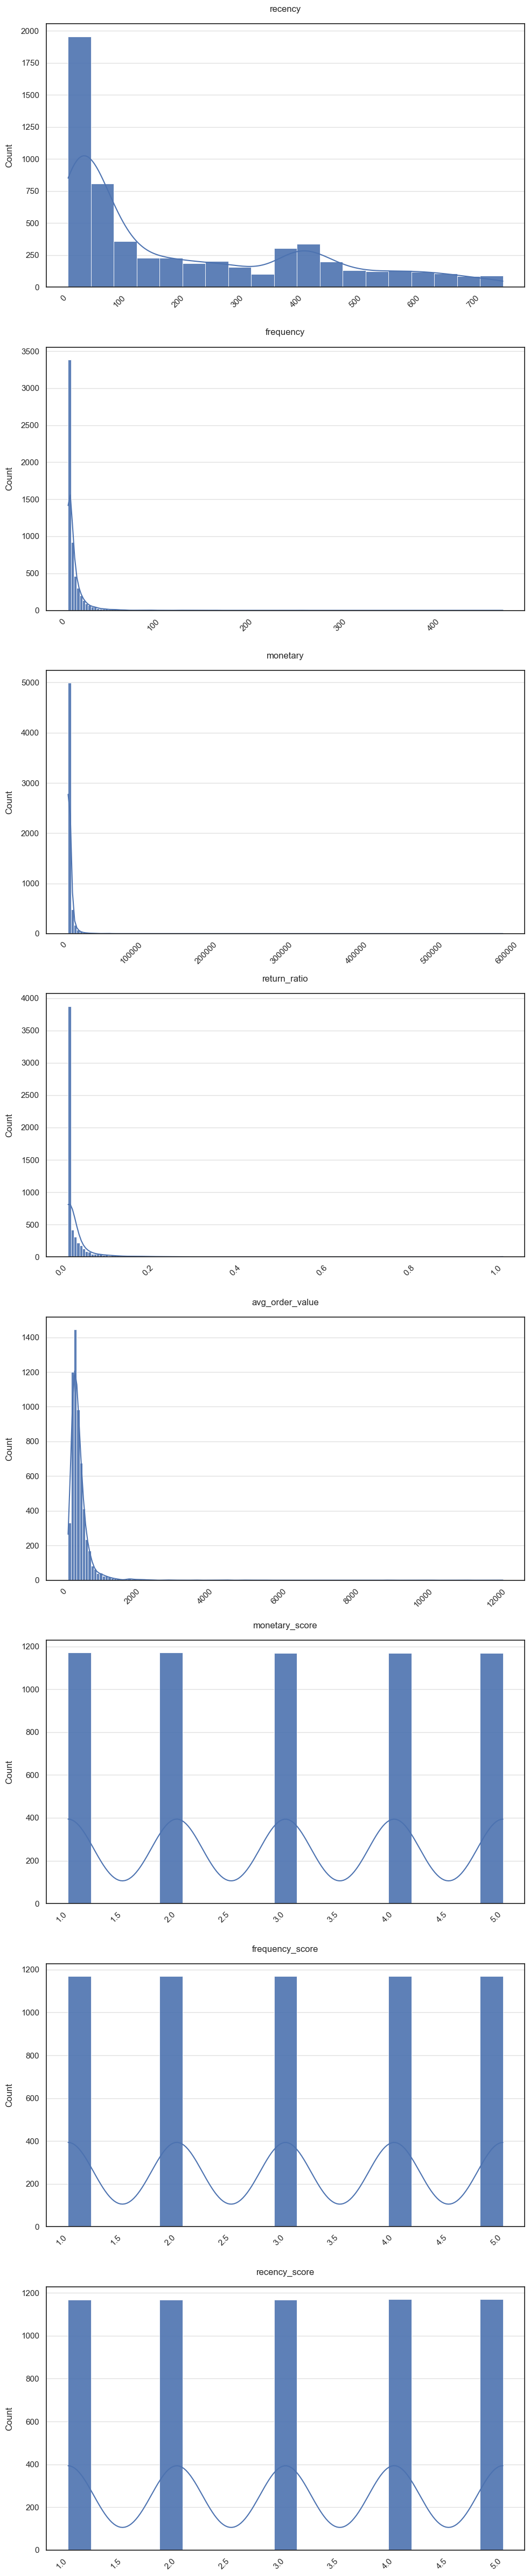

In [14]:
features = ['recency', 'frequency', 'monetary', 'return_ratio', 'avg_order_value', 'monetary_score', 'frequency_score', 'recency_score']

plots(data=df, features=features, kind='hist', kde=True, showfliers=False, cols=1, figsize_per_row=(10, 6))

(<Figure size 1000x4800 with 8 Axes>,
 array([<Axes: title={'center': 'recency'}>,
        <Axes: title={'center': 'frequency'}>,
        <Axes: title={'center': 'monetary'}>,
        <Axes: title={'center': 'return_ratio'}>,
        <Axes: title={'center': 'avg_order_value'}>,
        <Axes: title={'center': 'monetary_score'}>,
        <Axes: title={'center': 'frequency_score'}>,
        <Axes: title={'center': 'recency_score'}>], dtype=object))

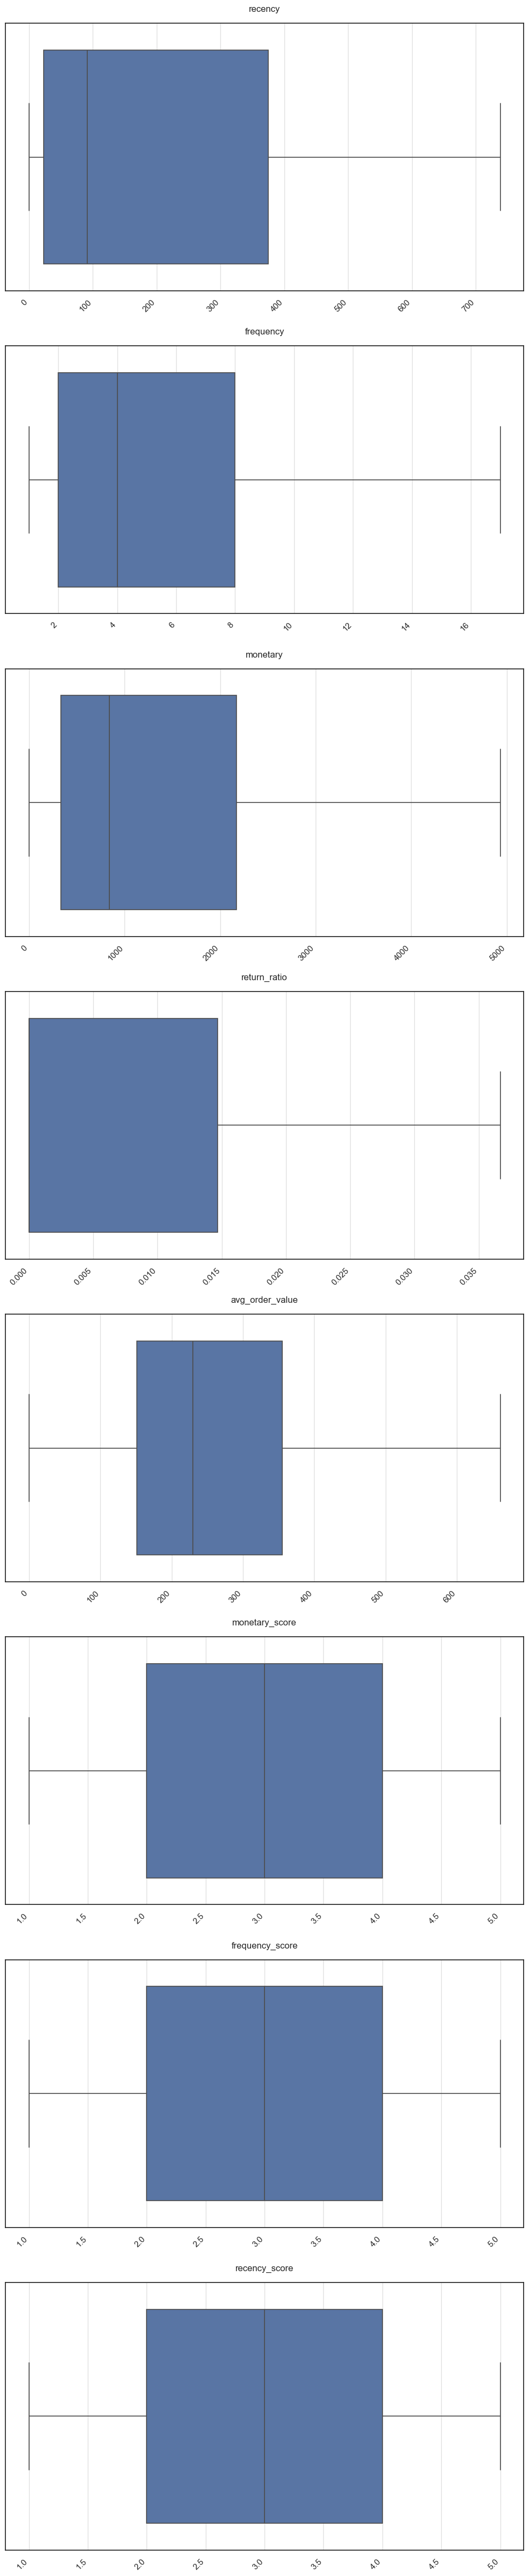

In [15]:
features = ['recency', 'frequency', 'monetary', 'return_ratio', 'avg_order_value', 'monetary_score', 'frequency_score', 'recency_score']
plots(data=df, features=features, kind='box', showfliers=False, cols=1, figsize_per_row=(10, 6))

(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'segment'}, ylabel='count'>], dtype=object))

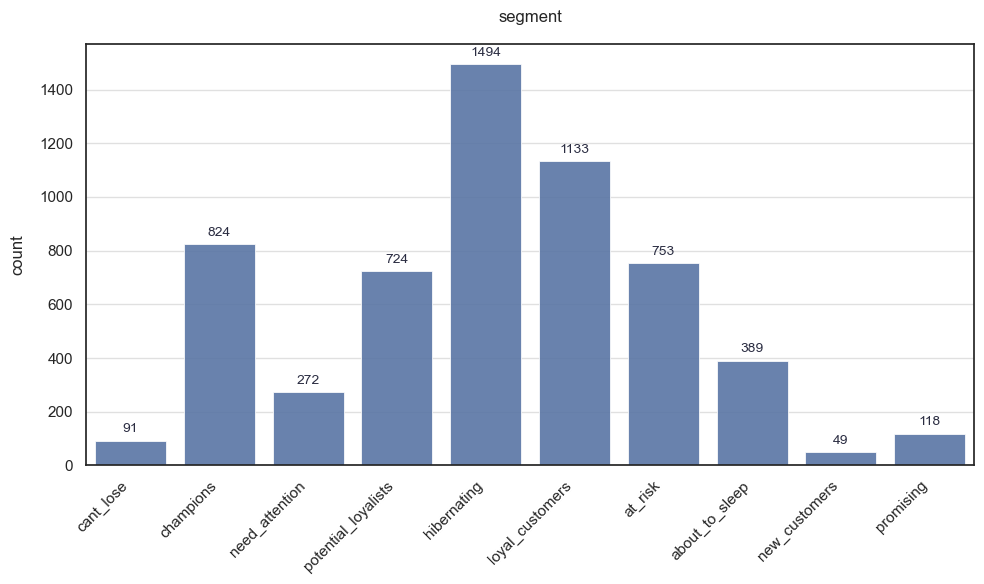

In [16]:
plots(data=df, features=['segment'], kind='count', cols=1, figsize_per_row=(10, 6))

(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'segment'}, ylabel='monetary'>],
       dtype=object))

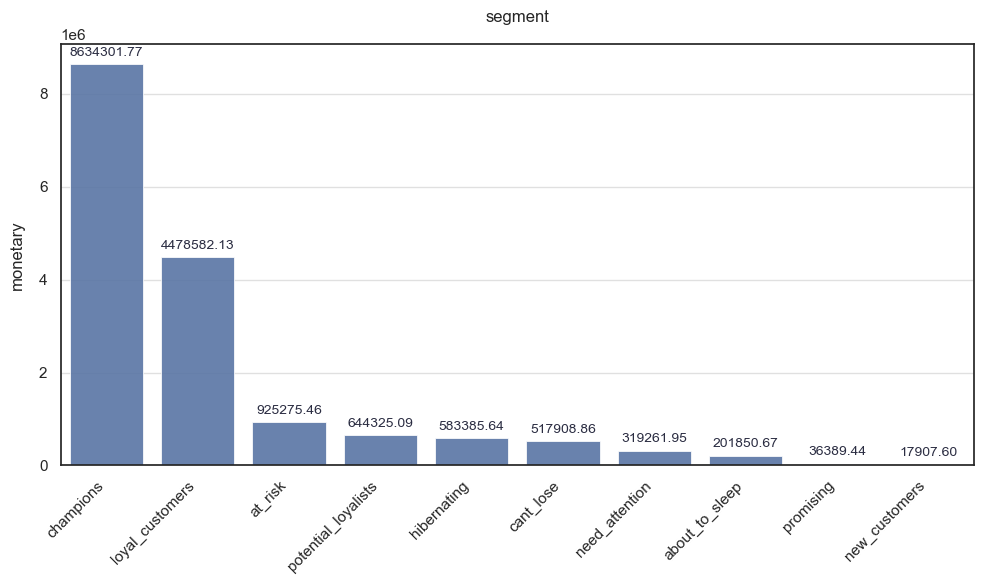

In [17]:
data = df.groupby('segment')['monetary'].sum().reset_index().sort_values('monetary', ascending=False)

plots(data=data, features=['segment'], kind='bar', value='monetary', cols=1, figsize_per_row=(10, 6))

(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'segment'}, ylabel='return_ratio'>],
       dtype=object))

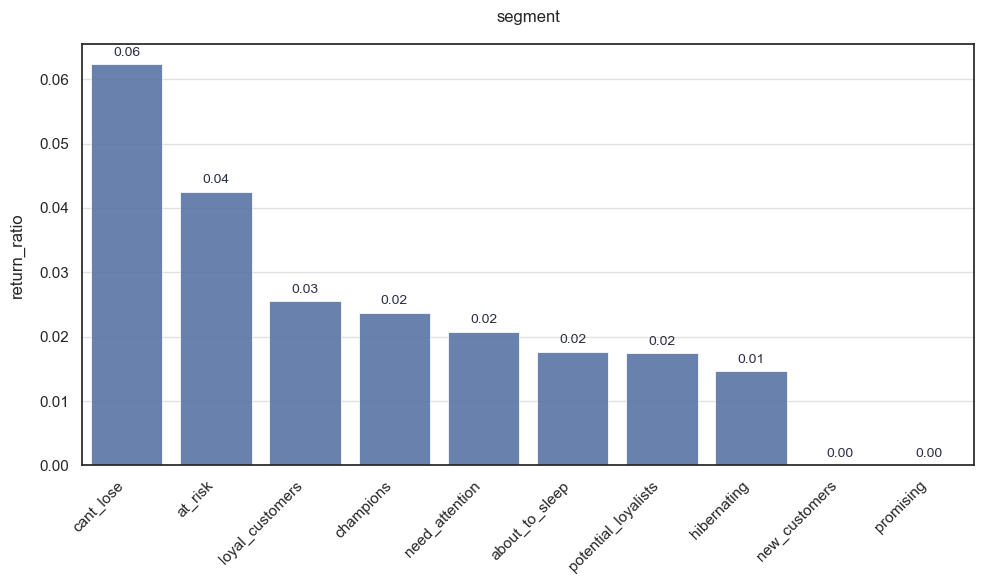

In [18]:
data = df.groupby('segment')['return_ratio'].mean().reset_index().sort_values('return_ratio', ascending=False)

plots(data=data, features=['segment'], kind='bar', value='return_ratio', cols=1, figsize_per_row=(10, 6))